In [10]:
#Task 2:-
import pandas as pd 

df = pd.read_csv("Dataset1.csv")

# DATASET INSPECTION

# Display shape of dataset (rows, columns)
print("Dataset Shape:", df.shape)

# Show column names
print("Column Names:", df.columns)

# Identify numerical and categorical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

# Detect missing values
print("Missing Values in each column:")
print(df.isnull().sum())


Dataset Shape: (14999, 10)
Column Names: Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')
Numerical Columns: Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years'],
      dtype='object')
Categorical Columns: Index(['Department', 'salary'], dtype='object')
Missing Values in each column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64


In [11]:
# DATA CLEANING

# Handle missing values in numerical columns using mean
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)

# Handle missing values in categorical columns using mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)

# Remove duplicate rows
df = df.drop_duplicates()

print("\nAfter removing duplicates, new shape:", df.shape)



After removing duplicates, new shape: (11991, 10)


In [12]:
# ENCODING CATEGORICAL VARIABLES
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Convert categorical columns into numerical values
df['Department'] = le.fit_transform(df['Department'])
df['salary'] = le.fit_transform(df['salary'])

print("\nDataset after Label Encoding:")
print(df.head())


Dataset after Label Encoding:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  Department  \
0                   3              0     1                      0           7   
1                   6              0     1                      0           7   
2                   4              0     1                      0           7   
3                   5              0     1                      0           7   
4                   3              0     1                      0           7   

 

In [13]:
# OUTLIER DETECTION USING IQR

# IQR method helps detect extreme values
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Remove rows where values are outside the range
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nShape after removing outliers:", df.shape)


# Final dataset preview
print("\nCleaned Dataset Preview:")
print(df.head())


Shape after removing outliers: (7566, 10)

Cleaned Dataset Preview:
      satisfaction_level  last_evaluation  number_project  \
2000                0.58             0.74               4   
2001                0.82             0.67               2   
2002                0.45             0.69               5   
2003                0.78             0.82               5   
2004                0.49             0.60               3   

      average_montly_hours  time_spend_company  Work_accident  left  \
2000                   215                   3              0     0   
2001                   202                   3              0     0   
2002                   193                   3              0     0   
2003                   247                   3              0     0   
2004                   214                   2              0     0   

      promotion_last_5years  Department  salary  
2000                      0           7       1  
2001                      0          

In [14]:
#-----------------------------------------------------------

In [15]:
#Task 3:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (replace with your dataset file name)
df = pd.read_csv("health_care.csv")

In [16]:
# BASIC DATA CHECK

print("First 5 rows of dataset:")
print(df.head())

# Identify numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

First 5 rows of dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


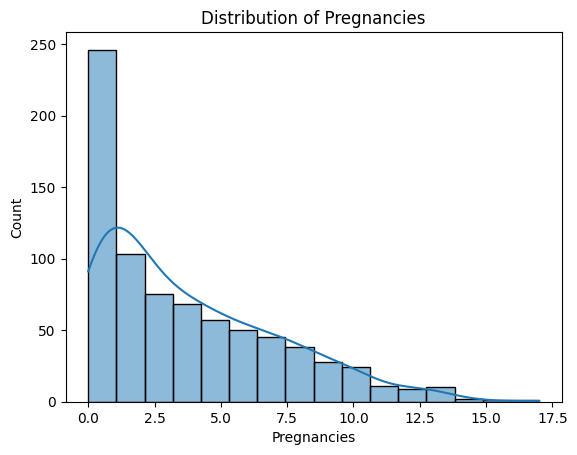

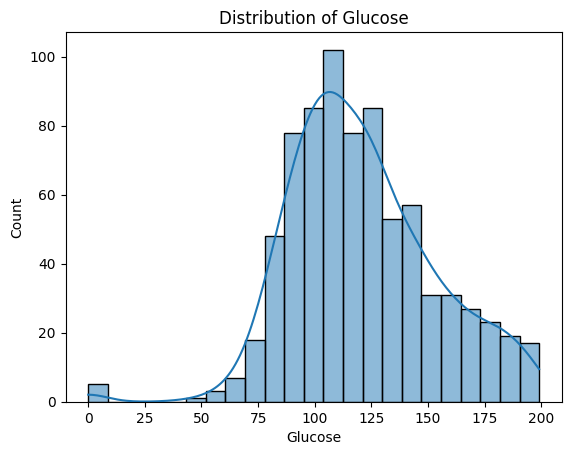

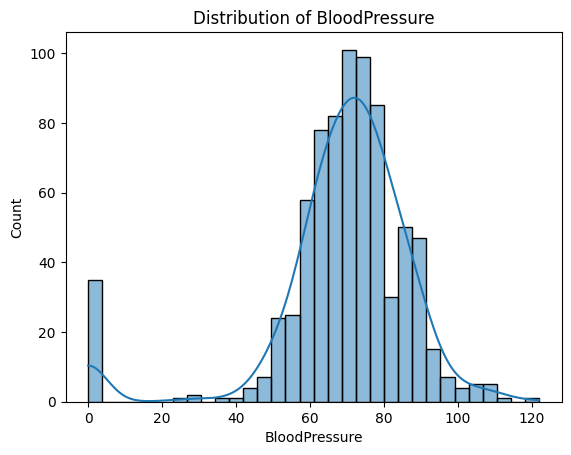

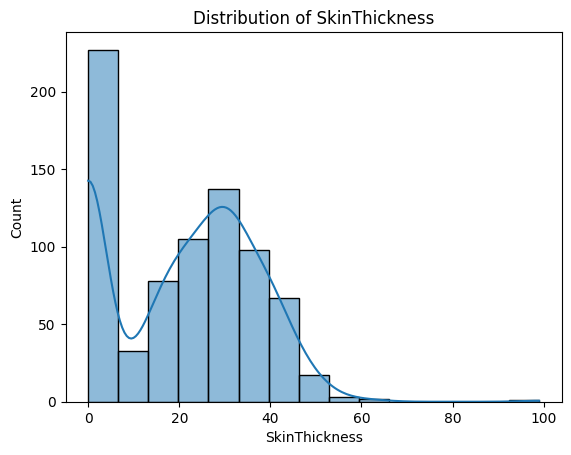

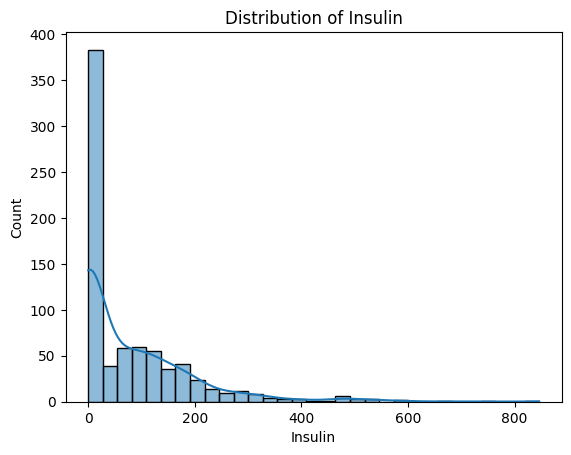

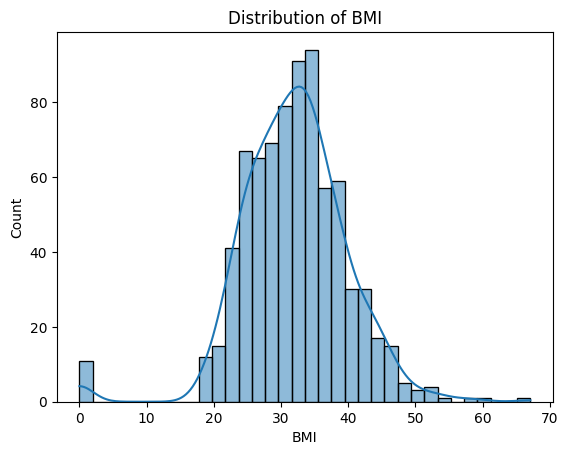

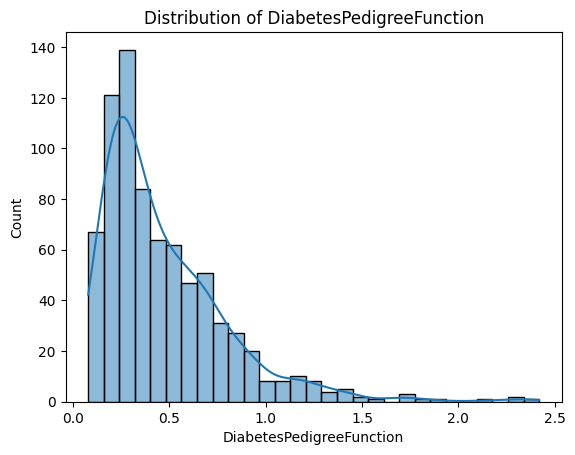

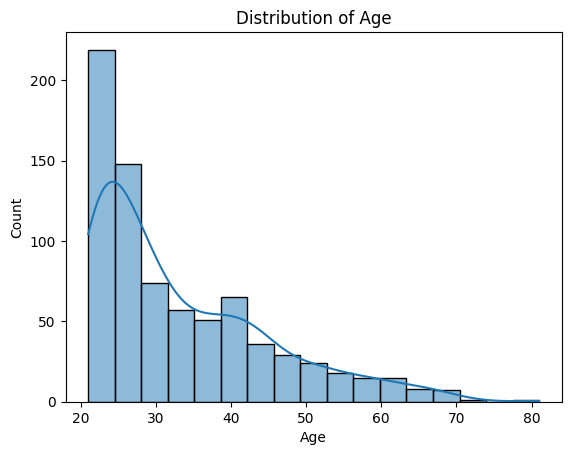

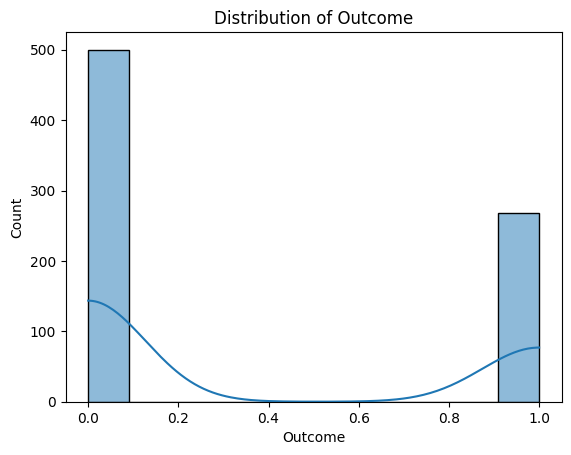

In [17]:
# DISTRIBUTION PLOT
# Plot distribution of numerical features

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title("Distribution of " + col)
    plt.show()

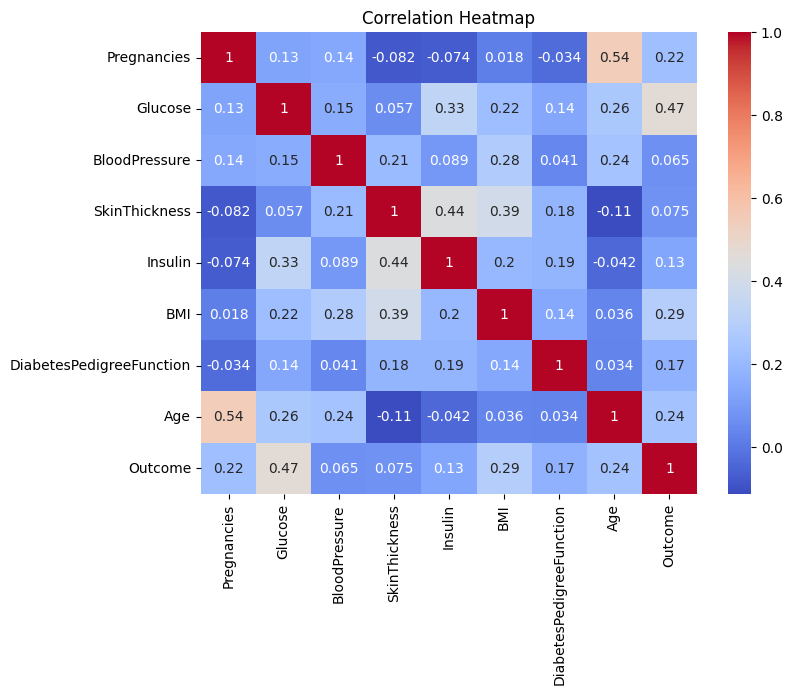

In [18]:
# CORRELATION HEATMAP

plt.figure(figsize=(8,6))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# COUNT PLOT FOR CATEGORICAL DATA

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title("Count Plot of " + col)
    plt.xticks(rotation=45)
    plt.show()

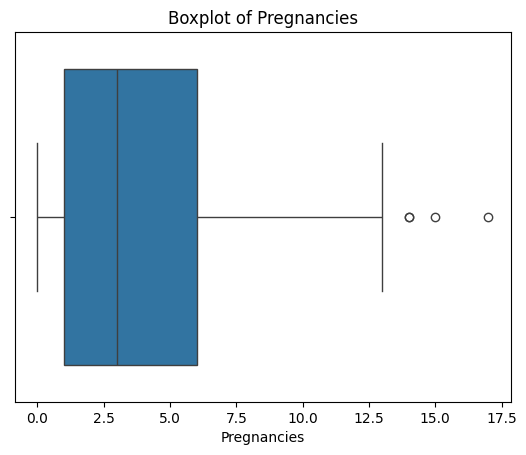

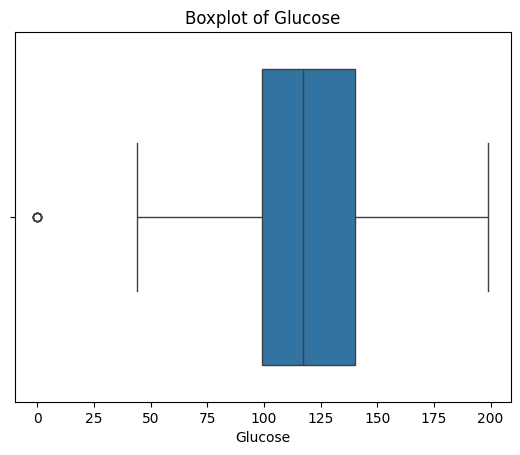

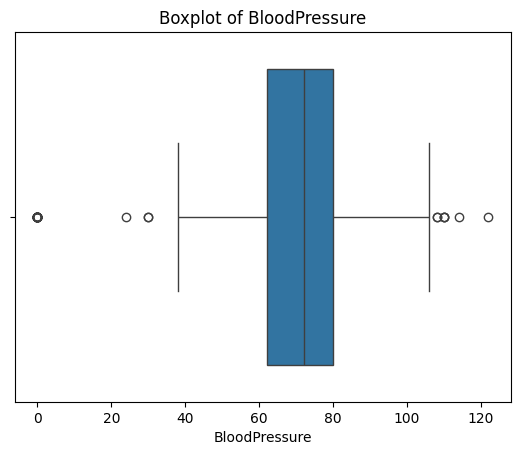

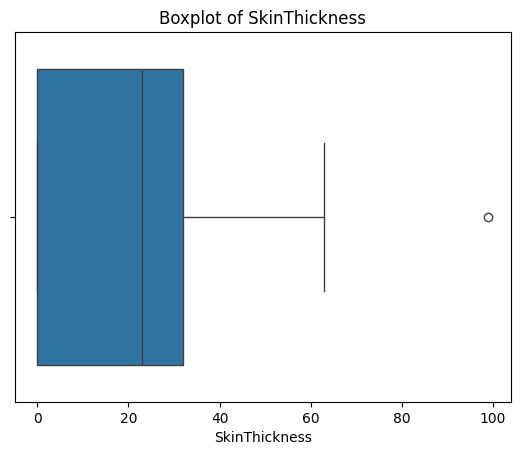

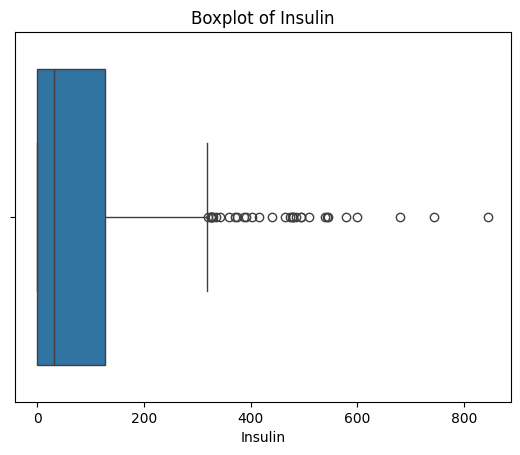

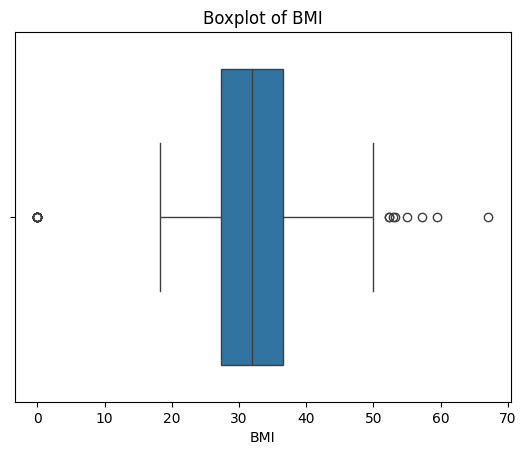

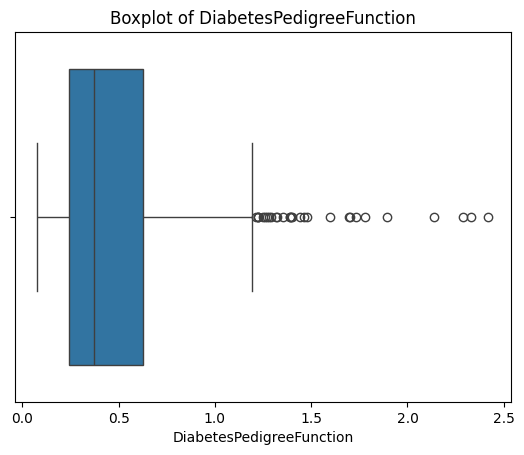

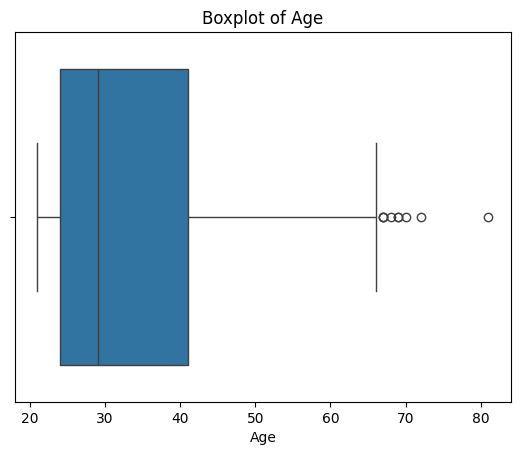

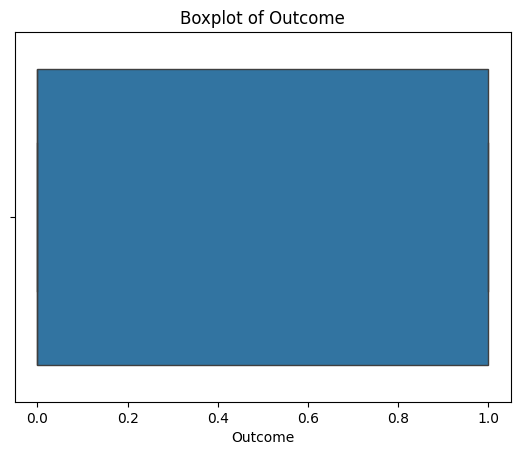

In [20]:
# BOXPLOT FOR OUTLIERS

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title("Boxplot of " + col)
    plt.show()

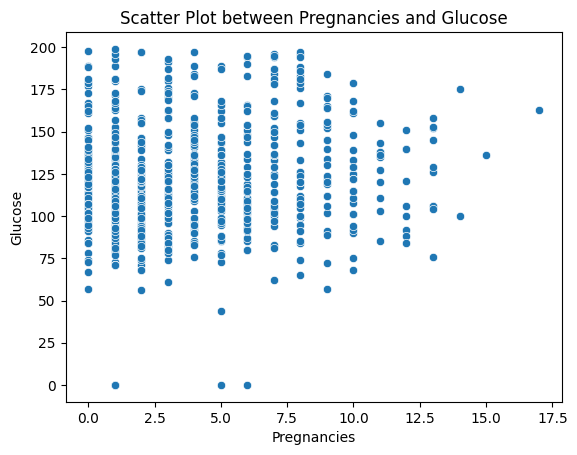

In [21]:
# SCATTER PLOT BETWEEN TWO VARIABLES

if len(num_cols) >= 2:
    plt.figure()
    sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]])
    plt.title("Scatter Plot between " + num_cols[0] + " and " + num_cols[1])
    plt.show()


In [22]:
#--------------------------------------------------------------------

In [23]:
#Task 4:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("health_care.csv")

In [24]:
# DROPPING IRRELEVANT COLUMNS
columns_to_drop = ["PassengerId", "Name"]  
for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(col, axis=1)

print("Columns after dropping unnecessary ones:")
print(df.columns)

Columns after dropping unnecessary ones:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [25]:
# CREATING A NEW FEATURE
# Combine two columns to create a new useful feature.

if "SibSp" in df.columns and "Parch" in df.columns:
    
    # FamilySize = number of siblings/spouse + parents/children + 1 (the person)
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [26]:
# SELECT IMPORTANT FEATURES
# Assume the target column is called "Survived" or "Target"

target_column = "Target"

if target_column not in df.columns:
    target_column = df.columns[-1]   


# Features (X) = all columns except target
X = df.drop(target_column, axis=1)

# Target (y)
y = df[target_column]

print("Feature columns:")
print(X.columns)

print("Target column:", target_column)


Feature columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')
Target column: Outcome


In [27]:
# TRAIN TEST SPLIT (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (614, 8)
Testing data size: (154, 8)


In [28]:
#--------------------------------------------------------------------------

In [29]:
#Task 5:

# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load dataset
df = pd.read_csv("health_care.csv")

In [30]:
# PREPARING DATA

# Assume the last column is the target variable
target = df.columns[-1]

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# MODEL 1 - LOGISTIC REGRESSION

#Train the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)


In [32]:
# MODEL 2 - DECISION TREE

tree_model = DecisionTreeClassifier()

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

In [33]:
# MODEL EVALUATION FUNCTION

def evaluate_model(y_true, y_pred, model_name):
    
    print("\nResults for", model_name)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# Evaluate both models
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_tree, "Decision Tree")


Results for Logistic Regression
Accuracy: 0.7467532467532467
Precision: 0.7501539408866995
Recall: 0.7467532467532467
F1 Score: 0.7481668773704172
Confusion Matrix:
[[78 21]
 [18 37]]

Results for Decision Tree
Accuracy: 0.7272727272727273
Precision: 0.7381824524681667
Recall: 0.7272727272727273
F1 Score: 0.7307760927743085
Confusion Matrix:
[[74 25]
 [17 38]]


In [34]:
# FEATURE IMPORTANCE

# Decision Tree can show which features are important
print("\nFeature Importance from Decision Tree:")

importance = tree_model.feature_importances_

for i in range(len(X.columns)):
    print(X.columns[i], ":", importance[i])



Feature Importance from Decision Tree:
Pregnancies : 0.07485398079581167
Glucose : 0.29709190820508896
BloodPressure : 0.13771150291831036
SkinThickness : 0.06654350605574938
Insulin : 0.052768717891863506
BMI : 0.16923410111732193
DiabetesPedigreeFunction : 0.09862324407917511
Age : 0.10317303893667906


In [35]:
#Which model performs best?
"""In this experiment, the Decision Tree model performed better than Logistic Regression 
because it achieved higher accuracy and F1 score during the evaluation."""

'In this experiment, the Decision Tree model performed better than Logistic Regression \nbecause it achieved higher accuracy and F1 score during the evaluation.'

In [36]:
#Why did it perform better?
"""The Decision Tree performed better because it can handle complex and non-linear relationships between features and the target variable.
Logistic Regression works best when the relationship between variables is linear, but many real-world datasets have more complicated patterns."""

'The Decision Tree performed better because it can handle complex and non-linear relationships between features and the target variable.\nLogistic Regression works best when the relationship between variables is linear, but many real-world datasets have more complicated patterns.'

In [ ]:
#Which features influened the prediction the most?
"""The Decision Tree model provides feature importance values, which show which features were most important for making predictions.
Features with higher importance scores influenced the prediction more than others.
Glucose, BMI, Blood Pressure, Age are important features which influenced the prediction the most"""

'The Decision Tree model provides feature importance values, which show which features were most important for making predictions.\nFeatures with higher importance scores influenced the prediction more than others.'

In [38]:
#-------------------------------------------------------------------------------------

In [39]:
#Task 6:

# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("health_care.csv")

In [40]:
# PREPARE DATA

target = df.columns[-1]

X = df.drop(target, axis=1)
y = df[target]

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# FEATURE SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# HYPERPARAMETER TUNING

model = LogisticRegression(max_iter=1000)

param_grid = {
    "C": [0.01, 0.1, 1, 10],     # regularization strength
    "solver": ["lbfgs", "liblinear"]
}

grid = GridSearchCV(model, param_grid, cv=5)

# Train the model with different parameter combinations
grid.fit(X_train_scaled, y_train)

# Best model found by GridSearch
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'solver': 'lbfgs'}


In [43]:
# MODEL EVALUATION

# Make predictions using the improved model
y_pred = best_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("Improved Model Accuracy:", accuracy)

Improved Model Accuracy: 0.7532467532467533
